# Tartu Area-Time Risk Prediction

The supplied CSV contains `incident_count`, this notebook derives a binary classification target called `high_risk` from that count.

Two comparable models are included:

1. **Logistic Regression**
2. **Random Forest Classifier**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/tartu_risk_dataset_2 - tartu_risk_dataset_2.csv.csv")

print(f"Loaded rows: {len(df):,}")
display(df.head())

Loaded rows: 38,880


,id,area,time,population,area_km2,area_population_density,foot_traffic,area_type,socially_vulnerable_zone,minorities_zone,student_zone,nightlife_zone,day_of_week,hour,is_weekend,is_night,weather,incident_count
0,1,Annelinn,2026-01-28 0:00:00,24981,4.910,5088,medium,residential,1,1,0,1,Wednesday,0,0,1,clear,1
1,2,Ihaste,2026-01-28 0:00:00,3050,4.800,635,low,residential,0,0,0,0,Wednesday,0,0,1,clear,0
2,3,Jaamamõisa,2026-01-28 0:00:00,3464,1.500,2309,low,residential,1,1,0,0,Wednesday,0,0,1,clear,0
3,4,Karlova,2026-01-28 0:00:00,8748,2.683,3261,medium,residential,1,0,1,1,Wednesday,0,0,1,clear,0
4,5,Kesklinn,2026-01-28 0:00:00,6956,1.799,3867,high,commercial,1,1,1,1,Wednesday,0,0,1,clear,1


In [4]:
df = df.copy()
if "time" in df.columns:
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df["month"] = df["time"].dt.month
    df["day_of_month"] = df["time"].dt.day

risk_threshold = max(1, int(np.ceil(df["incident_count"].quantile(0.75))))
df["high_risk"] = (df["incident_count"] >= risk_threshold).astype(int)

print(f"High-risk threshold: incident_count >= {risk_threshold}")

High-risk threshold: incident_count >= 1


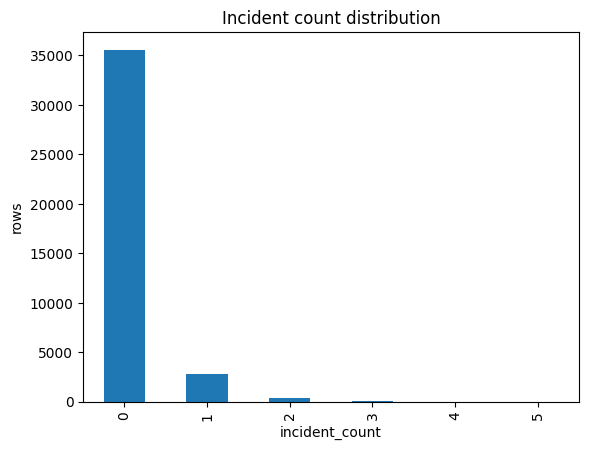

In [5]:
ax = df["incident_count"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Incident count distribution")
ax.set_xlabel("incident_count")
ax.set_ylabel("rows")
plt.show()

Excluded columns:

- `incident_count`: source count target, not a feature.
- `high_risk`: derived classification target.
- `id`: row identifier.
- `time`: raw timestamp; derived calendar fields are used instead.

In [6]:
target_col = "high_risk"
exclude_cols = {"id", "time", "incident_count", target_col}
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df[target_col]

categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Train rows: {len(X_train):,}")
print(f"Test rows:  {len(X_test):,}")

Train rows: 31,104
Test rows:  7,776


In [8]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

In [9]:
models = {
    "logistic_regression": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=42)),
        ]
    ),
    "random_forest": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=100,
                max_depth=None,
                min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=1,
            )),
        ]
    ),
}

models

{'logistic_regression': Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['population', 'area_km2',
                                                    'area_population_density',
                                                    'socially_vulnerable_zone',
                                                    'minorities_zone',
                                                    'student_zone',
                                                    'nightlife_zone', 'hour',
                                                    'is_weekend', 'is_night',
      

In [10]:
results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
display(results_df)

,model,accuracy,precision,recall,f1,roc_auc
1,random_forest,0.88696,0.350136,0.389985,0.368988,0.768332
0,logistic_regression,0.74910,0.217163,0.752656,0.337071,0.812110


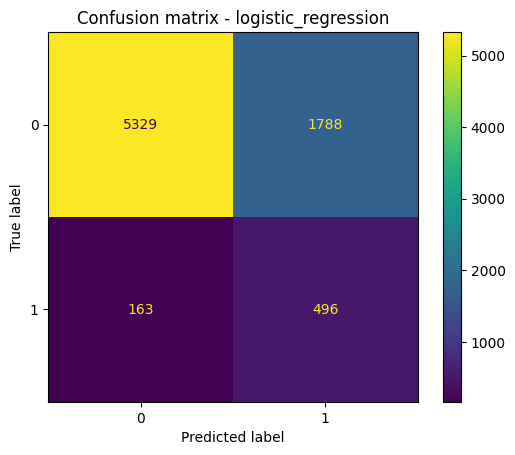

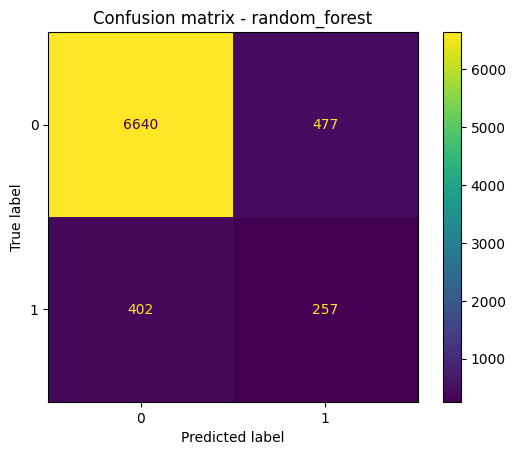

In [11]:
for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion matrix - {name}")
    plt.show()

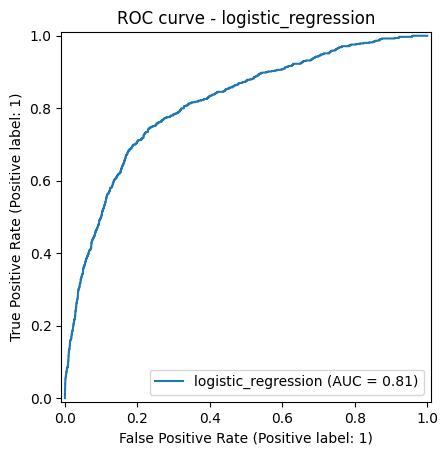

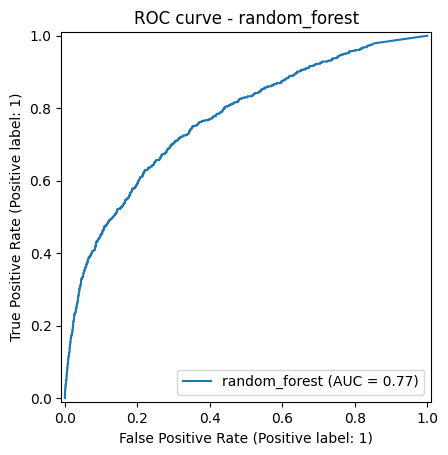

In [12]:
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name)
    plt.title(f"ROC curve - {name}")
    plt.show()

,feature,importance
7,hour,0.245789
11,day_of_month,0.127480
2,area_population_density,0.065385
6,nightlife_zone,0.062888
10,month,0.062403
31,foot_traffic_low,0.061314
0,population,0.046928
9,is_night,0.028785
5,student_zone,0.022428
1,area_km2,0.020130


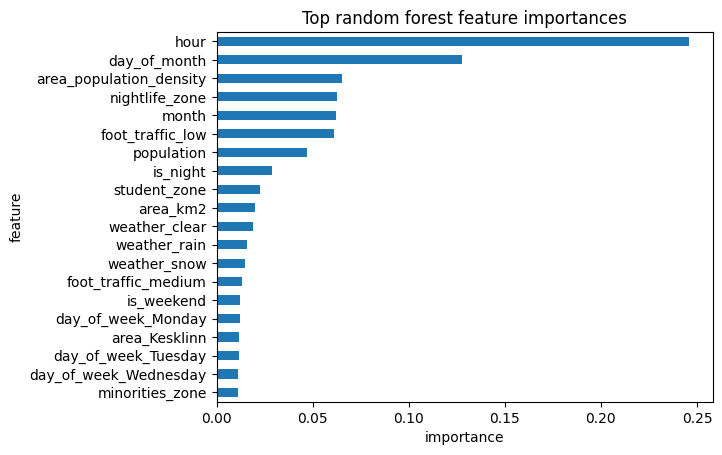

In [13]:
def get_feature_names_from_preprocessor(preprocessor):
    names = []
    if numeric_features:
        names.extend(numeric_features)
    if categorical_features:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        names.extend(ohe.get_feature_names_out(categorical_features).tolist())
    return names

rf_model = fitted_models["random_forest"]
feature_names = get_feature_names_from_preprocessor(rf_model.named_steps["preprocess"])
importances = rf_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

display(importance_df)

ax = importance_df.sort_values("importance").plot(kind="barh", x="feature", y="importance", legend=False)
ax.set_title("Top random forest feature importances")
ax.set_xlabel("importance")
ax.set_ylabel("feature")
plt.show()

In [14]:
def predict_risk_scores(model, feature_frame):

    required = list(X.columns)
    missing = set(required) - set(feature_frame.columns)
    if missing:
        raise ValueError(f"Missing required feature columns: {sorted(missing)}")

    out = feature_frame.copy()
    out["predicted_high_risk"] = model.predict(feature_frame[required])
    out["risk_score"] = model.predict_proba(feature_frame[required])[:, 1]
    return out

best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

example_scores = predict_risk_scores(best_model, X.head(10))
print(f"Best model by F1: {best_model_name}")
display(example_scores)

Best model by F1: random_forest


,area,population,area_km2,area_population_density,foot_traffic,area_type,socially_vulnerable_zone,minorities_zone,student_zone,nightlife_zone,day_of_week,hour,is_weekend,is_night,weather,month,day_of_month,predicted_high_risk,risk_score
0,Annelinn,24981,4.910,5088,medium,residential,1,1,0,1,Wednesday,0,0,1,clear,1,28,1,0.519429
1,Ihaste,3050,4.800,635,low,residential,0,0,0,0,Wednesday,0,0,1,clear,1,28,0,0.025609
2,Jaamamõisa,3464,1.500,2309,low,residential,1,1,0,0,Wednesday,0,0,1,clear,1,28,0,0.081263
3,Karlova,8748,2.683,3261,medium,residential,1,0,1,1,Wednesday,0,0,1,clear,1,28,0,0.106831
4,Kesklinn,6956,1.799,3867,high,commercial,1,1,1,1,Wednesday,0,0,1,clear,1,28,1,0.622140
5,Kvissentali,865,1.509,573,low,residential,0,0,0,0,Wednesday,0,0,1,clear,1,28,0,0.005918
6,Maarjamõisa,477,1.133,421,low,residential,0,0,0,0,Wednesday,0,0,1,clear,1,28,0,0.000000
7,Raadi-Kruusamäe,4804,2.828,1699,low,residential,0,0,0,0,Wednesday,0,0,1,clear,1,28,0,0.016072
8,Ropka,4710,1.442,3266,low,mixed,1,1,0,0,Wednesday,0,0,1,clear,1,28,0,0.469452
9,Ropka tööstuse,2198,3.249,676,low,commercial,1,1,0,0,Wednesday,0,0,1,clear,1,28,0,0.015016
